## CONSTRAINED

In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))
#IMPORTS
import matplotlib.pyplot as plt
import scipy.io as sio
import pandas as pd
import numpy as np
from sklearn.decomposition import FastICA
from src.visualizacion import *
from src.evaluacion import *
from src.metricas import *
from src.preprocesamiento import *
from src.io_utils import *
from src.sobi import *
from scipy import signal
from src.generador import *
from src.constrained_ica import constrained_fastICA
#VARIABLES
fs=1000
window_size=200
salto=50

In [2]:
mat=load_mat("C:/Users/34648/Desktop/Clases/4_GITT/TFG/OPENICPSR/TR2_postTMR_32chanEMG.mat")

In [3]:
X1, key1 = find_movement_rep(mat, movement="HandOpen", rep=1)
X2, key2 = find_movement_rep(mat, movement="noMotion", rep=1)  

print("Señal 1 extraída de:", key1)
print("Señal 2 extraída de:", key2)


ch_s1 = 4
ch_s2 = 21
ch_s3 = 4

u1 = eliminar_continua(X1[:, ch_s1].astype(float))
u2_raw = eliminar_continua(X1[:, ch_s2].astype(float))  


#Longitudes
N = min(len(u1), len(u2_raw))
u1 = u1[:N]

u2_raw = u2_raw[:N]
N = len(u1)
t = np.arange(N) / fs

m1 = np.zeros(N)
m2 = np.zeros(N)
m3 = np.zeros(N)
# ejemplo por bloques de 0.5 s
bloque = int(0.2 * fs)
bloque2 = int(0.2 * fs)
# patrón:
# 0: ninguno
# 1: solo s1
# 2: solo s2
# 3: ambos
patron = [0, 3, 2,1, 3, 3, 1, 2, 3, 0,2, 3,1]

for i, estado in enumerate(patron):
    a = i * bloque
    a2= i * bloque2
    b = min((i + 1) * bloque, N)
    b2= min((i + 1) * bloque2, N)
    if estado == 1:
        m1[a:b] = 1.0
        m3[a:b] = 1.0
    elif estado == 2:
        m2[a2:b2] = 1.0
    elif estado == 3:
        m1[a:b] = 1.0
        m3[a:b] = 1.0
        m2[a2:b2] = 1.0


#CONSTRUCCION DE SEÑALES

s1 = m1 * u1
s2 = m2 * u2_raw


#RETARDOS DE S2
tau_ms = 10
tau = int(fs * tau_ms / 1000)

s2_delayed = np.zeros_like(s2)

if tau < len(s2):
    s2_delayed[tau:] = s2[:-tau]

#MEZCLAS
beta = 1
noise_std = 0.0

rng = np.random.default_rng(0)
n1 = noise_std * rng.standard_normal(len(s1))
n2 = noise_std * rng.standard_normal(len(s1))

c1 = 1.0 * s1 + beta * s2_delayed + n1
c2 = 0.01 * s1 + 1.0 * s2 + n2

X_mix = np.column_stack([c1, c2])
S_true = np.column_stack([s1, s2_delayed])

Señal 1 extraída de: HandOpen_1.DAQ_DATA
Señal 2 extraída de: NoMotion_1.DAQ_DATA


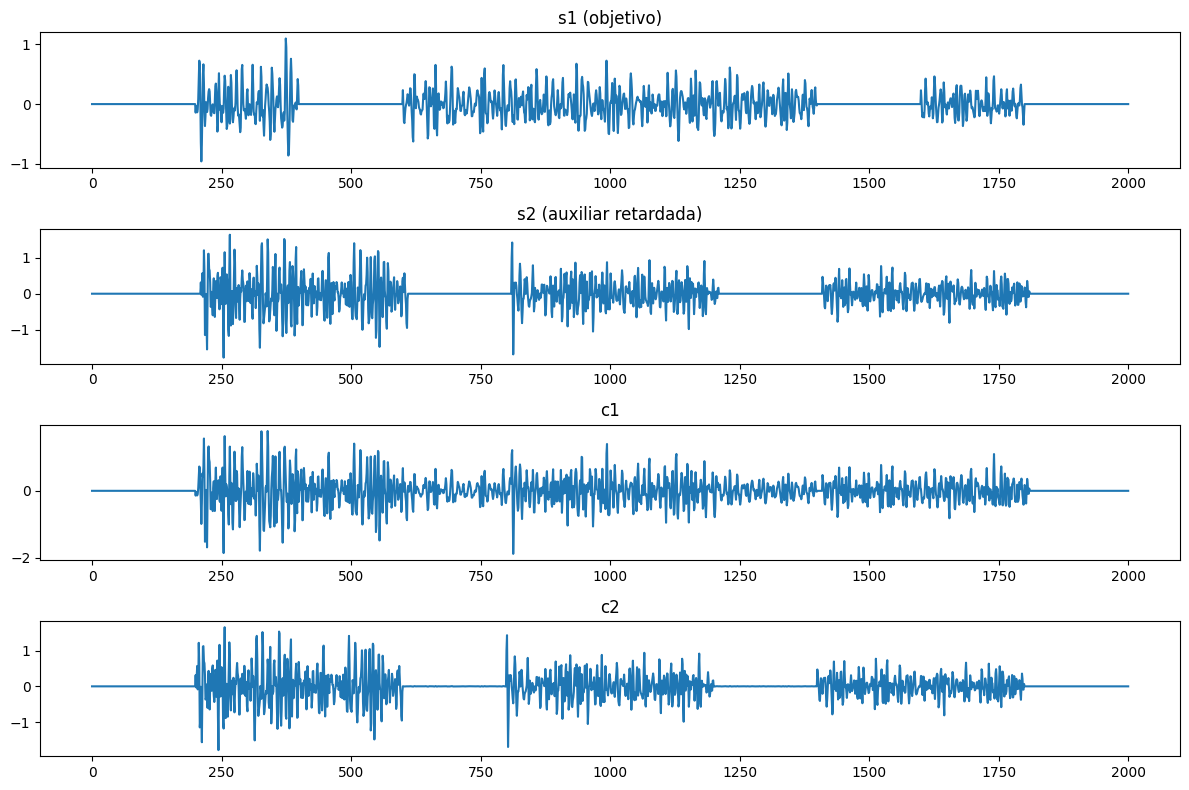

In [4]:
plt.figure(figsize=(12, 8))

plt.subplot(4, 1, 1)
plt.plot(s1)
plt.title("s1 (objetivo)")

plt.subplot(4, 1, 2)
plt.plot(s2_delayed)
plt.title("s2 (auxiliar retardada)")

plt.subplot(4, 1, 3)
plt.plot(c1)
plt.title("c1")

plt.subplot(4, 1, 4)
plt.plot(c2)
plt.title("c2")

plt.tight_layout()
plt.show()

## EXPERIMENTOS

### 1. Región trivial

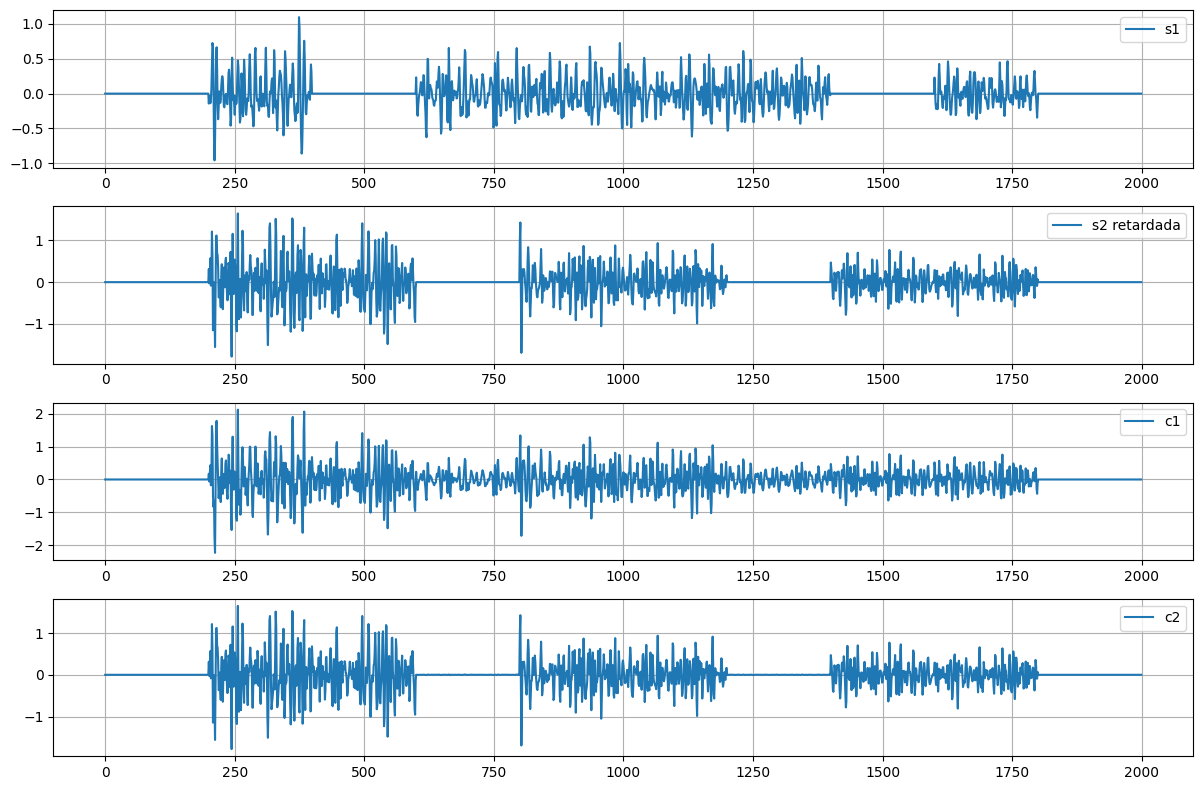

,method,source,corr,corr_rms,rms_true,rms_est,rms_rel_error,rel_mae_rms_env
0,FastICA,s1,0.999876,0.999952,0.183965,1.00000,4.435805,4.449648
1,FastICA,s2,0.999997,0.999999,0.323386,1.00000,2.092280,2.093715
2,Constrained (anti-ref s2),s1,0.995177,0.997654,0.183965,0.99975,4.434446,4.505374
3,Constrained (anti-ref s2),s2,0.993246,0.997659,0.323386,0.99975,2.091507,2.146487
4,Constrained (ref imperfecta),s1,0.938956,0.965306,0.183965,0.99975,4.434446,4.662232
5,Constrained (ref imperfecta),s2,0.945009,0.976368,0.323386,0.99975,2.091507,2.233615


,method,corr,corr_rms,rms_rel_error,rel_mae_rms_env
0,FastICA,0.999876,0.999952,4.435805,4.449648
1,Constrained (anti-ref s2),0.995177,0.997654,4.434446,4.505374
2,Constrained (ref imperfecta),0.938956,0.965306,4.434446,4.662232


In [5]:

# Caso trivial: sin ruido, sin retardo, fuentes de amplitud comparable.
case_trivial = build_case(
    u1=u1, u2_raw=u2_raw, fs=fs,
    a11=1.0, a21=0.01, beta=1.0,
    tau_ms=0.0, noise_std=0.0,
    block_ms=200,
    random_state=0
)

show_case_signals(case_trivial, n_samples=2000)

out_trivial = run_methods_on_case(case_trivial, lambda_ref=5.0, random_state=0)
display(out_trivial["df"])
display(summarize_s1(out_trivial["df"]))


### 2. Fuente objetivo debil

,method,source,corr,corr_rms,rms_true,rms_est,rms_rel_error,rel_mae_rms_env,target_scale
0,FastICA,s1,0.973294,0.994666,0.183965,1.00000,4.435805,4.691334,1.0
1,Constrained (anti-ref s2),s1,0.962465,0.992108,0.183965,0.99975,4.434446,4.725123,1.0
2,Constrained (ref imperfecta),s1,0.711658,0.794251,0.183965,0.99975,4.434446,4.852783,1.0
3,FastICA,s1,0.947760,0.990030,0.128776,1.00000,6.765435,7.260690,0.7
4,Constrained (anti-ref s2),s1,0.936967,0.987617,0.128776,0.99975,6.763495,7.292910,0.7
5,Constrained (ref imperfecta),s1,0.819584,0.911162,0.128776,0.99975,6.763495,7.427663,0.7
6,FastICA,s1,0.904439,0.982618,0.091983,1.00000,9.871609,10.768519,0.5
7,Constrained (anti-ref s2),s1,0.893399,0.980059,0.091983,0.99975,9.868892,10.796851,0.5
8,Constrained (ref imperfecta),s1,0.838072,0.949809,0.091983,0.99975,9.868892,10.884948,0.5
9,FastICA,s1,0.783852,0.962508,0.055190,1.00000,17.119349,19.130714,0.3


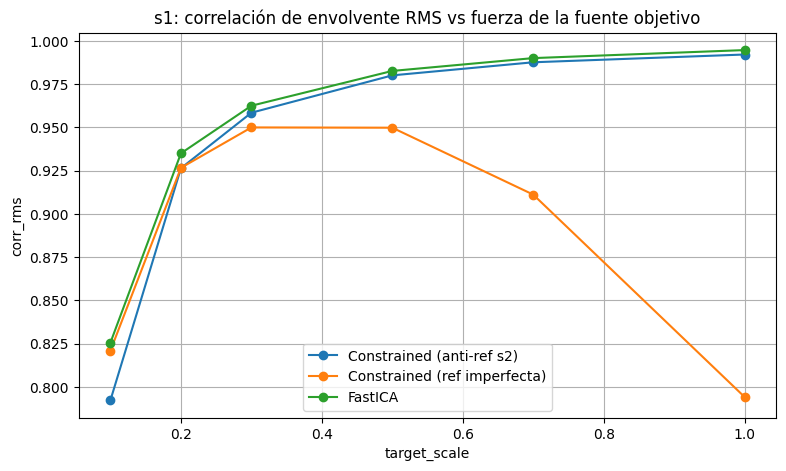

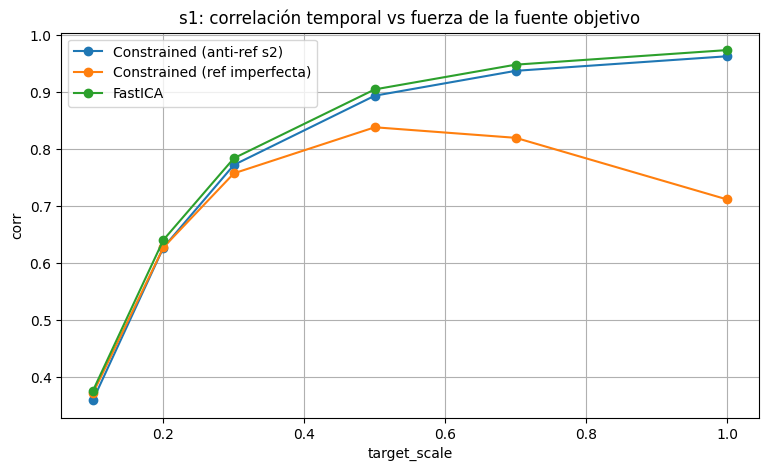

In [6]:

# === 2. Fuente objetivo débil ===
# Idea: reducir la contribución efectiva de s1 para ver cuándo la restricción ayuda.

base_case = dict(
    u1=u1,
    u2_raw=u2_raw,
    fs=fs,
    a11=1.0,
    a21=0.01,
    beta=1.0,
    tau_ms=0.0,
    noise_std=0.03,
    block_ms=200,
)

weak_vals = [1.0, 0.7, 0.5, 0.3, 0.2, 0.1]
df_weak = run_grid(
    param_name="target_scale",
    values=weak_vals,
    base_case_kwargs=base_case,
    lambda_ref=5.0,
    random_state=0
)

display(df_weak.head(12))
plot_metric_vs_param(df_weak, "target_scale", metric="corr_rms",
                     title="s1: correlación de envolvente RMS vs fuerza de la fuente objetivo")
plot_metric_vs_param(df_weak, "target_scale", metric="corr",
                     title="s1: correlación temporal vs fuerza de la fuente objetivo")


### 3. Coactivacion creciente

,method,source,corr,corr_rms,rms_true,rms_est,rms_rel_error,rel_mae_rms_env,coactivacion
0,FastICA,s1,0.953147,0.994567,0.134462,1.00000,6.437063,7.990173,baja
1,Constrained (anti-ref s2),s1,0.951704,0.994358,0.134462,0.99975,6.435204,8.011283,baja
2,Constrained (ref imperfecta),s1,0.880212,0.926887,0.134462,0.99975,6.435204,8.849563,baja
3,FastICA,s1,0.969783,0.994139,0.171230,1.00000,4.840113,5.232638,media
4,Constrained (anti-ref s2),s1,0.696445,0.782466,0.171230,0.99975,4.838653,5.228459,media
5,Constrained (ref imperfecta),s1,0.925942,0.980491,0.171230,0.99975,4.838653,5.350218,media
6,FastICA,s1,0.967566,0.992970,0.216370,1.00000,3.621718,3.759183,alta
7,Constrained (anti-ref s2),s1,0.795119,0.917287,0.216370,0.99975,3.620563,3.870950,alta
8,Constrained (ref imperfecta),s1,0.977915,0.994912,0.216370,0.99975,3.620563,3.732183,alta
9,FastICA,s1,0.953408,0.986105,0.227291,1.00000,3.399652,3.473860,muy_alta


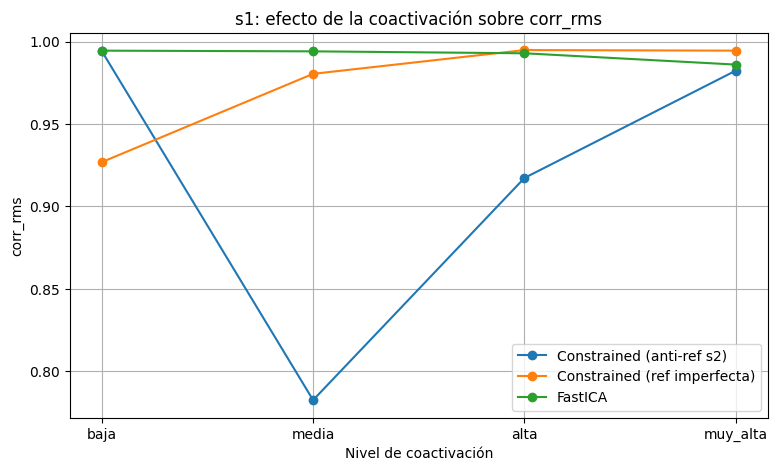

In [7]:

# === 3. Coactivación creciente ===
# Idea: cuando s1 y s2 se activan casi siempre juntos, la información binaria de referencia ayuda menos.

patterns = {
    "baja":   [0,1,0,2,0,1,2,0,1,0,2,0,1],
    "media":  [0,3,2,1,3,0,1,2,3,0,2,3,1],
    "alta":   [3,3,1,3,2,3,3,1,3,2,3,3,1],
    "muy_alta":[3,3,3,1,3,3,2,3,3,3,1,3,3],
}

rows = []
for level, patt in patterns.items():
    case = build_case(
        u1=u1, u2_raw=u2_raw, fs=fs,
        a11=1.0, a21=0.01, beta=1.0,
        tau_ms=0.0, noise_std=0.03,
        pattern=patt, block_ms=200,
        random_state=0
    )
    out = run_methods_on_case(case, lambda_ref=5.0, random_state=0)
    tmp = out["df"][out["df"]["source"]=="s1"].copy()
    tmp["coactivacion"] = level
    rows.append(tmp)

df_coact = pd.concat(rows, ignore_index=True)
display(df_coact)

plt.figure(figsize=(9,5))
for method, g in df_coact.groupby("method"):
    g = g.set_index("coactivacion").loc[list(patterns.keys())].reset_index()
    plt.plot(g["coactivacion"], g["corr_rms"], marker="o", label=method)
plt.title("s1: efecto de la coactivación sobre corr_rms")
plt.xlabel("Nivel de coactivación")
plt.ylabel("corr_rms")
plt.grid(True)
plt.legend()
plt.show()


### 4. Retardo pequeño

,method,source,corr,corr_rms,rms_true,rms_est,rms_rel_error,rel_mae_rms_env,tau_ms
0,FastICA,s1,0.973294,0.994666,0.183965,1.00000,4.435805,4.691334,0
1,Constrained (anti-ref s2),s1,0.962465,0.992108,0.183965,0.99975,4.434446,4.725123,0
2,Constrained (ref imperfecta),s1,0.711658,0.794251,0.183965,0.99975,4.434446,4.852783,0
3,FastICA,s1,0.216557,0.417542,0.183965,1.00000,4.435805,4.447701,2
4,Constrained (anti-ref s2),s1,0.138518,0.393885,0.183965,0.99975,4.434446,4.474052,2
5,Constrained (ref imperfecta),s1,0.419661,0.511935,0.183965,0.99975,4.434446,4.564777,2
6,FastICA,s1,0.047251,0.379615,0.183965,1.00000,4.435805,4.534817,5
7,Constrained (anti-ref s2),s1,0.081722,0.387120,0.183965,0.99975,4.434446,4.525180,5
8,Constrained (ref imperfecta),s1,0.344688,0.509872,0.183965,0.99975,4.434446,4.655332,5
9,FastICA,s1,0.046507,0.380054,0.183965,1.00000,4.435805,4.527063,8


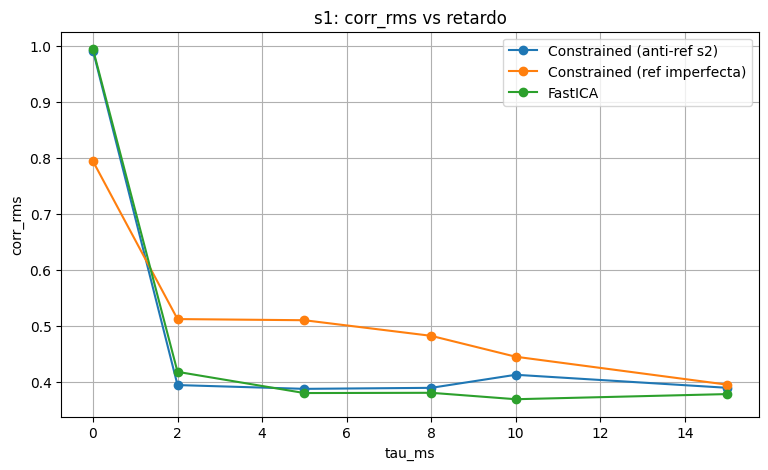

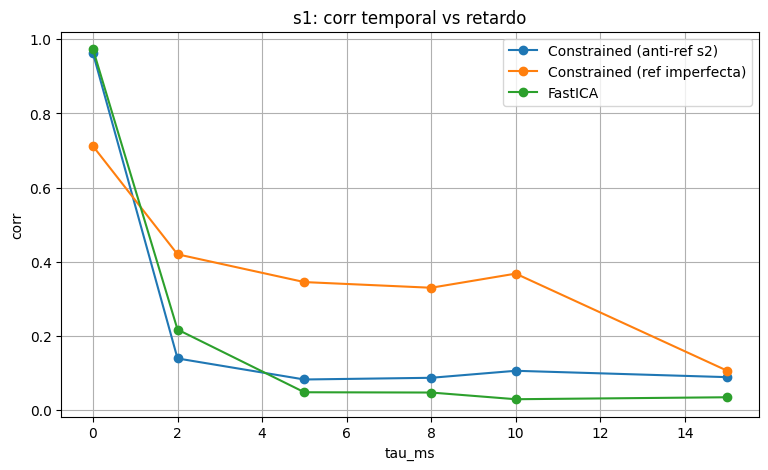

In [8]:

# === 4. Retardo pequeño ===
# Idea: al aumentar tau, la hipótesis de mezcla instantánea se rompe más.

tau_vals = [0, 2, 5, 8, 10, 15]
base_case = dict(
    u1=u1,
    u2_raw=u2_raw,
    fs=fs,
    a11=1.0,
    a21=0.01,
    beta=1.0,
    noise_std=0.03,
    block_ms=200,
)

df_tau = run_grid(
    param_name="tau_ms",
    values=tau_vals,
    base_case_kwargs=base_case,
    lambda_ref=5.0,
    random_state=0
)

display(df_tau)
plot_metric_vs_param(df_tau, "tau_ms", metric="corr_rms",
                     title="s1: corr_rms vs retardo")
plot_metric_vs_param(df_tau, "tau_ms", metric="corr",
                     title="s1: corr temporal vs retardo")


### 5. Ventanas cortas

,method,source,corr,corr_rms,rms_true,rms_est,rms_rel_error,rel_mae_rms_env,window_ms
0,FastICA,s1,0.259121,0.361341,0.183965,1.00000,4.435805,4.974865,50
1,Constrained (anti-ref s2),s1,0.509084,0.535182,0.183965,0.99975,4.434446,5.123511,50
2,FastICA,s1,0.259121,0.400695,0.183965,1.00000,4.435805,4.768827,100
3,Constrained (anti-ref s2),s1,0.509084,0.563528,0.183965,0.99975,4.434446,4.885333,100
4,FastICA,s1,0.259121,0.422996,0.183965,1.00000,4.435805,4.697692,150
5,Constrained (anti-ref s2),s1,0.509084,0.581719,0.183965,0.99975,4.434446,4.800483,150
6,FastICA,s1,0.259121,0.527073,0.183965,1.00000,4.435805,4.467049,200
7,Constrained (anti-ref s2),s1,0.509084,0.661661,0.183965,0.99975,4.434446,4.532161,200
8,FastICA,s1,0.259121,0.619424,0.183965,1.00000,4.435805,4.289948,300
9,Constrained (anti-ref s2),s1,0.509084,0.739857,0.183965,0.99975,4.434446,4.353113,300


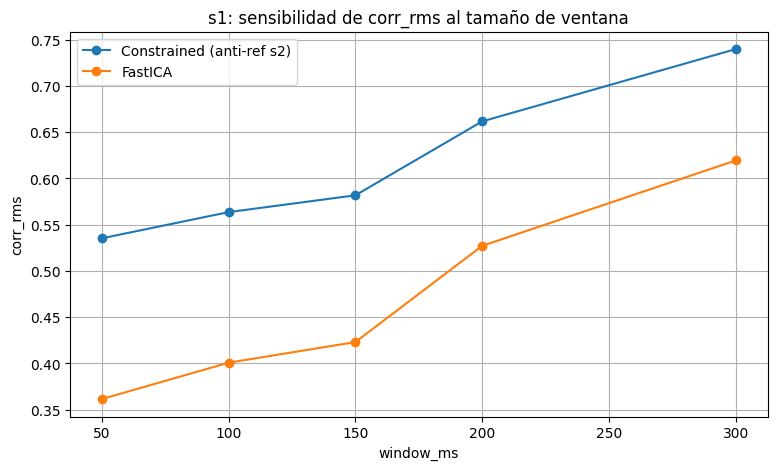

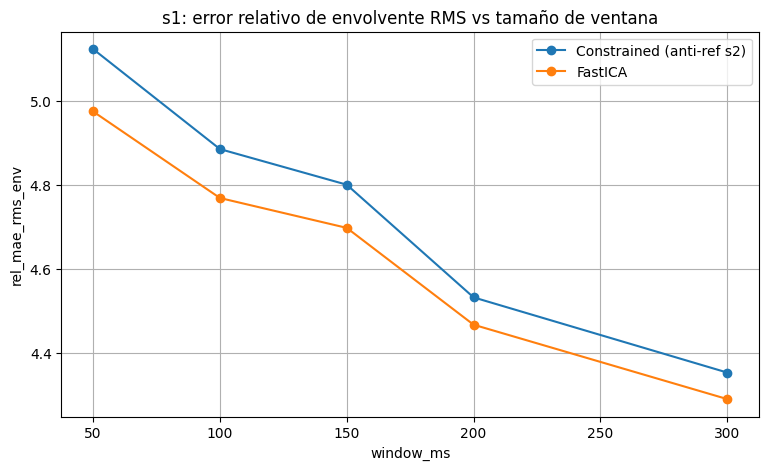

In [ ]:

# === 5. Ventanas cortas ===


case = build_case(
    u1=u1, u2_raw=u2_raw, fs=fs,
    a11=1.0, a21=0.01, beta=1,
    tau_ms=2.0, noise_std=0.1,
    block_ms=200,
    random_state=0
)

X = case["X"]
S_true = case["S_true"]
S_ica, _ = run_fastica(X, random_state=0)
S_con, _ = constrained_fastICA(
    X, ref=case["ref_bad"], constrain_row=0,
    n_components=2, random_state=0, hard_ref=True, lambda_ref=5.0
)

wins = [50, 100, 150, 200, 300]
rows = []

for w in wins:
    df_ica, _, _ = evaluate_method("FastICA", S_ica, S_true, fs=fs, window_ms=w, step_ms=max(20, w//3))
    df_con, _, _ = evaluate_method("Constrained (anti-ref s2)", S_con, S_true, fs=fs, window_ms=w, step_ms=max(20, w//3))
    tmp = pd.concat([df_ica, df_con], ignore_index=True)
    tmp["window_ms"] = w
    rows.append(tmp[tmp["source"]=="s1"])

df_win = pd.concat(rows, ignore_index=True)
display(df_win)

plot_metric_vs_param(df_win, "window_ms", metric="corr_rms",
                     title="s1: sensibilidad de corr_rms al tamaño de ventana")
plot_metric_vs_param(df_win, "window_ms", metric="rel_mae_rms_env",
                     title="s1: error relativo de envolvente RMS vs tamaño de ventana")


### 6. Referencia imperfecta

,method,source,corr,corr_rms,rms_true,rms_est,rms_rel_error,rel_mae_rms_env,ref_flip_prob
0,FastICA,s1,0.047251,0.379615,0.183965,1.00000,4.435805,4.534817,0.0
1,Constrained (anti-ref s2),s1,0.081722,0.387120,0.183965,0.99975,4.434446,4.525180,0.0
2,Constrained (ref imperfecta),s1,0.344688,0.509872,0.183965,0.99975,4.434446,4.655332,0.0
3,FastICA,s1,0.047251,0.379615,0.183965,1.00000,4.435805,4.534817,0.1
4,Constrained (anti-ref s2),s1,0.081722,0.387120,0.183965,0.99975,4.434446,4.525180,0.1
5,Constrained (ref imperfecta),s1,0.006032,0.377341,0.183965,0.99975,4.434446,4.526824,0.1
6,FastICA,s1,0.047251,0.379615,0.183965,1.00000,4.435805,4.534817,0.2
7,Constrained (anti-ref s2),s1,0.081722,0.387120,0.183965,0.99975,4.434446,4.525180,0.2
8,Constrained (ref imperfecta),s1,0.349344,0.512799,0.183965,0.99975,4.434446,4.659169,0.2
9,FastICA,s1,0.047251,0.379615,0.183965,1.00000,4.435805,4.534817,0.3


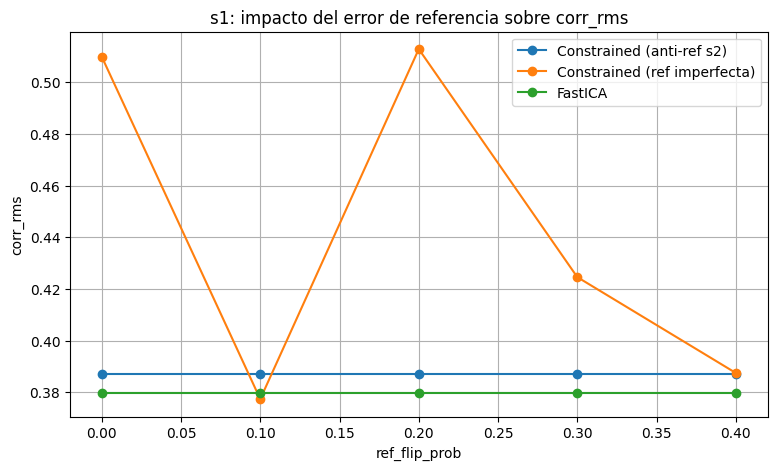

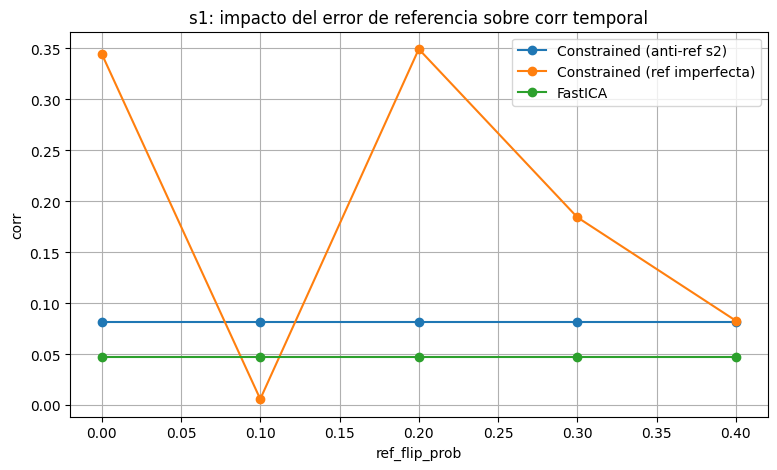

In [ ]:

# === 6. Referencia imperfecta ===


noise_ref_vals = [0.0, 0.1, 0.2, 0.3, 0.4]

rows = []
for p in noise_ref_vals:
    case = build_case(
        u1=u1, u2_raw=u2_raw, fs=fs,
        a11=1.0, a21=0.01, beta=1.0,
        tau_ms=5.0, noise_std=0.03,
        block_ms=200,
        ref_flip_prob=p,
        random_state=0
    )
    out = run_methods_on_case(case, lambda_ref=5.0, random_state=0)
    tmp = out["df"][out["df"]["source"]=="s1"].copy()
    tmp["ref_flip_prob"] = p
    rows.append(tmp)

df_ref = pd.concat(rows, ignore_index=True)
display(df_ref)

plot_metric_vs_param(df_ref, "ref_flip_prob", metric="corr_rms",
                     title="s1: impacto del error de referencia sobre corr_rms")
plot_metric_vs_param(df_ref, "ref_flip_prob", metric="corr",
                     title="s1: impacto del error de referencia sobre corr temporal")


### 7. Anti-referencia del contaminante

,method,source,corr,corr_rms,rms_true,rms_est,rms_rel_error,rel_mae_rms_env,beta
0,FastICA,s1,0.868408,0.928593,0.183965,1.00000,4.435805,4.808972,0.3
1,Constrained (anti-ref s2),s1,0.855050,0.916112,0.183965,0.99975,4.434446,4.807586,0.3
2,Constrained (ref imperfecta),s1,0.637686,0.722723,0.183965,0.99975,4.434446,4.784479,0.3
3,FastICA,s1,0.728523,0.808220,0.183965,1.00000,4.435805,4.823377,0.5
4,Constrained (anti-ref s2),s1,0.719246,0.798131,0.183965,0.99975,4.434446,4.813841,0.5
5,Constrained (ref imperfecta),s1,0.532861,0.637737,0.183965,0.99975,4.434446,4.752228,0.5
6,FastICA,s1,0.027463,0.377448,0.183965,1.00000,4.435805,4.534047,0.8
7,Constrained (anti-ref s2),s1,0.094123,0.390305,0.183965,0.99975,4.434446,4.517929,0.8
8,Constrained (ref imperfecta),s1,0.406099,0.547439,0.183965,0.99975,4.434446,4.690750,0.8
9,FastICA,s1,0.047251,0.379615,0.183965,1.00000,4.435805,4.534817,1.0


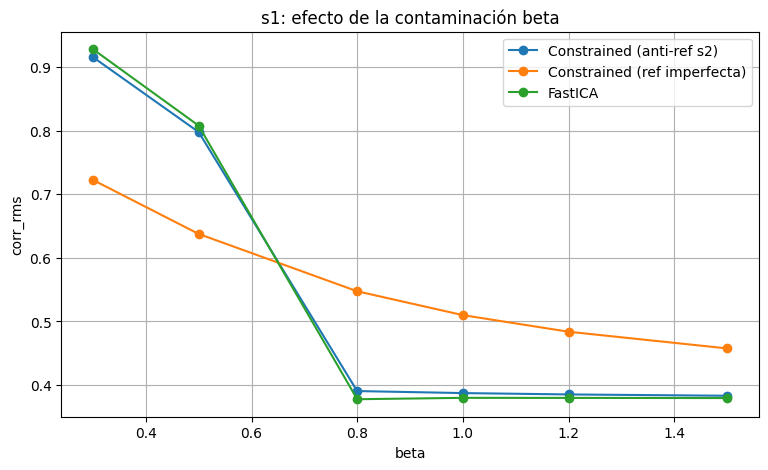

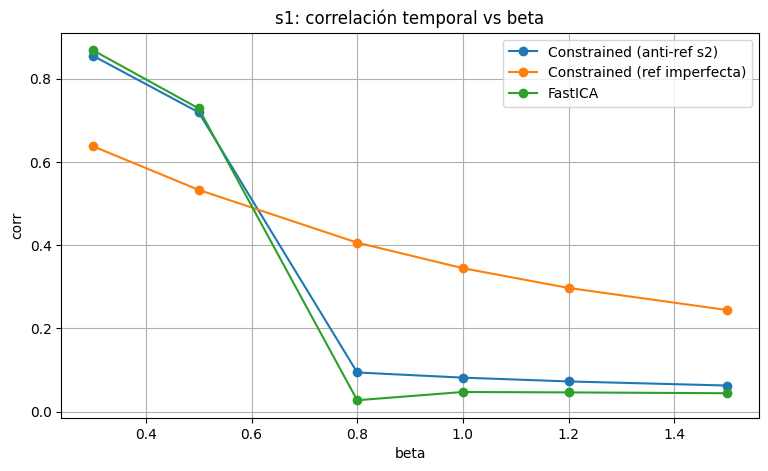

In [11]:

# === 7. Anti-referencia del contaminante ===
# Este es probablemente el experimento más alineado con tu implementación actual.

beta_vals = [0.3, 0.5, 0.8, 1.0, 1.2, 1.5]
rows = []

for beta_i in beta_vals:
    case = build_case(
        u1=u1, u2_raw=u2_raw, fs=fs,
        a11=1.0, a21=0.01, beta=beta_i,
        tau_ms=5.0, noise_std=0.03,
        block_ms=200,
        random_state=0
    )
    out = run_methods_on_case(case, lambda_ref=5.0, random_state=0)
    tmp = out["df"][out["df"]["source"]=="s1"].copy()
    tmp["beta"] = beta_i
    rows.append(tmp)

df_beta = pd.concat(rows, ignore_index=True)
display(df_beta)

plot_metric_vs_param(df_beta, "beta", metric="corr_rms",
                     title="s1: efecto de la contaminación beta")
plot_metric_vs_param(df_beta, "beta", metric="corr",
                     title="s1: correlación temporal vs beta")
